In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_excel("model_df_clean.xlsx")

In [3]:
spike_rows = df[df["Max_Static_Air_Temperature_degree_celsius"] > 50]

print("Rows in the spike:", len(spike_rows))

print("\nBy fleet:")
print(spike_rows["Fleet"].value_counts())

print("\nBy month:")
print(spike_rows["Date"].dt.to_period("M").value_counts().sort_index())

print("\nBy aircraft registration:")
print(spike_rows["Aircraft_Registration"].value_counts())

Rows in the spike: 524

By fleet:
Fleet
B737-NG     477
B737F-NG     47
Name: count, dtype: int64

By month:
Date
2026-03     13
2026-04    107
2026-05    276
2026-06      4
2026-08    124
Freq: M, Name: count, dtype: int64

By aircraft registration:
Aircraft_Registration
9XR-WY    227
9XR-WF    119
9XR-WG    118
9XR-WW     47
9XR-WR     13
Name: count, dtype: int64


In [4]:
df = df.drop(columns=["Max_Static_Air_Temperature_degree_celsius"])

print("Remaining columns:", df.columns.tolist())
print("Shape:", df.shape)
print("\nFleet counts:")
print(df["Fleet"].value_counts())

Remaining columns: ['Flight_ID', 'Flight_Number', 'Date', 'Fleet', 'Aircraft_Registration', 'Route', 'Total_Distance_Flown_NM', 'Great_Circle_Distance_NM', 'Gross_Weight_At_Liftoff_kg', 'Max_Tailwind_During_Takeoff_kt', 'Total_Fuel_Burn_kg']
Shape: (1404, 11)

Fleet counts:
Fleet
B737-NG     1074
A330         283
B737F-NG      47
Name: count, dtype: int64


In [5]:
print(df["Max_Tailwind_During_Takeoff_kt"].describe())

count    1404.000000
mean       -0.998575
std         4.345224
min       -16.000000
25%        -4.000000
50%        -1.000000
75%         2.000000
max        12.000000
Name: Max_Tailwind_During_Takeoff_kt, dtype: float64


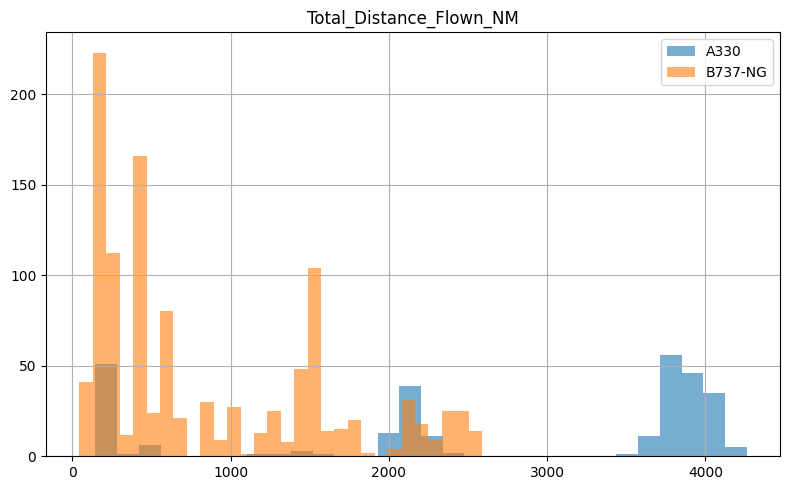

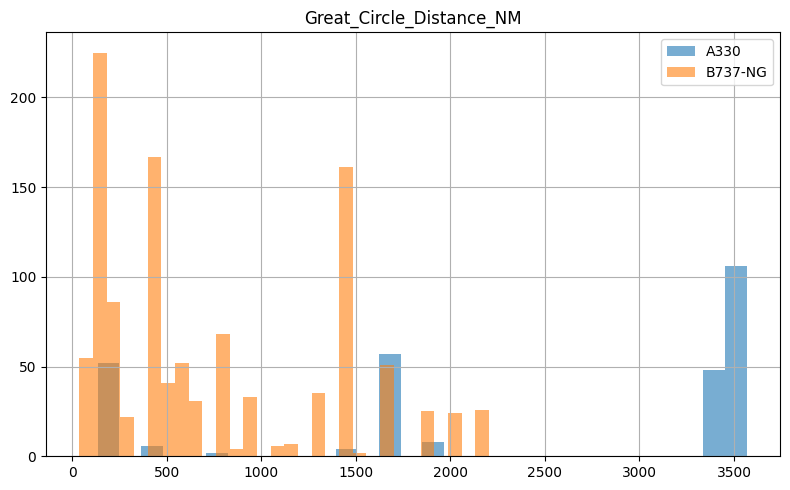

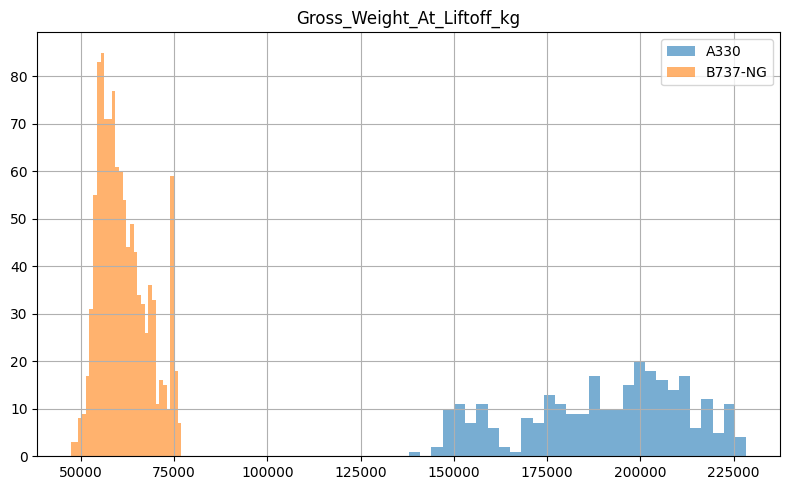

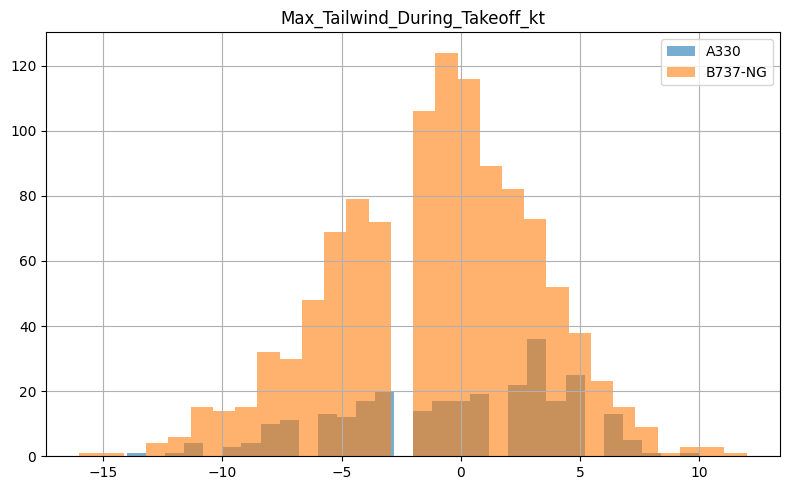

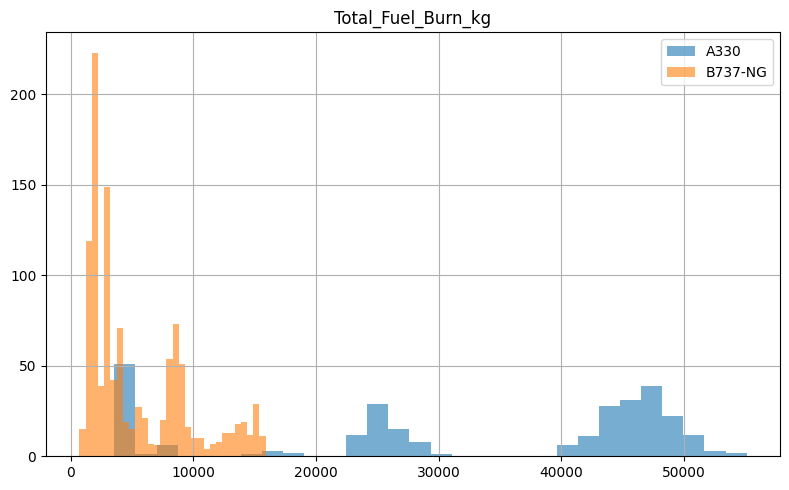

['.ipynb_checkpoints', 'by_fleet_Great_Circle_Distance_NM.png', 'by_fleet_Gross_Weight_At_Liftoff_kg.png', 'by_fleet_Max_Tailwind_During_Takeoff_kt.png', 'by_fleet_Total_Distance_Flown_NM.png', 'by_fleet_Total_Fuel_Burn_kg.png']


In [6]:
os.makedirs("images", exist_ok=True)

df["Fleet_Group"] = df["Fleet"].replace({"B737F-NG": "B737-NG"})

cols = ["Total_Distance_Flown_NM","Great_Circle_Distance_NM", "Gross_Weight_At_Liftoff_kg",
        "Max_Tailwind_During_Takeoff_kt", "Total_Fuel_Burn_kg"]

for col in cols:
    fig, ax = plt.subplots(figsize=(8, 5))
    for fleet in df["Fleet_Group"].unique():
        df[df["Fleet_Group"] == fleet][col].hist(bins=30, ax=ax, alpha=0.6, label=fleet)
    ax.set_title(col)
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"images/by_fleet_{col}.png", dpi=150)
    plt.show()

print(os.listdir("images"))

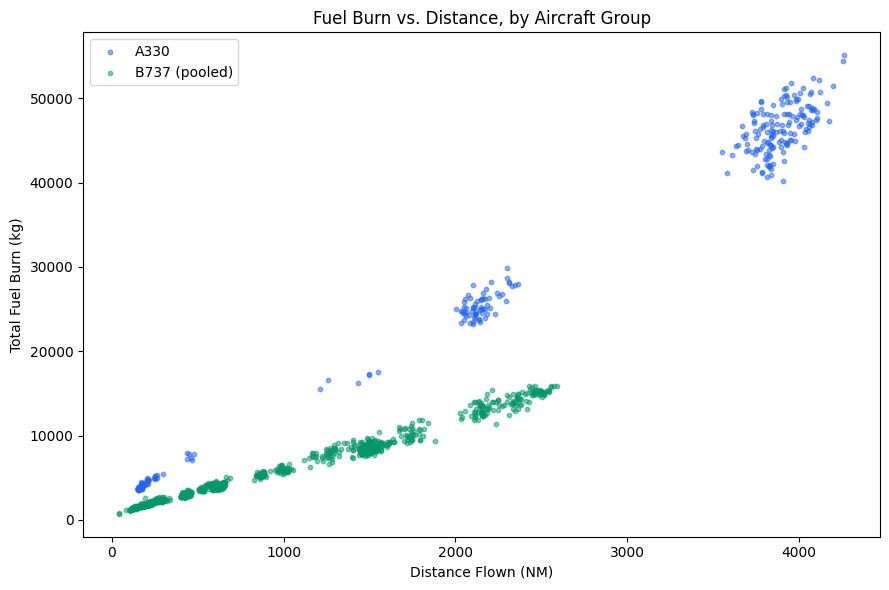

Saved: images/fuel_vs_distance.png


In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

fleet_groups = {
    "A330": ("A330", "#2563eb"),
    "B737-NG": ("B737 (pooled)", "#059669"),
    "B737F-NG": ("B737 (pooled)", "#059669"),
}

plotted_labels = set()
for fleet, (label, color) in fleet_groups.items():
    subset = df[df["Fleet"] == fleet]
    show_label = label if label not in plotted_labels else None
    ax.scatter(subset["Total_Distance_Flown_NM"], subset["Total_Fuel_Burn_kg"],
               s=10, alpha=0.5, label=show_label, color=color)
    plotted_labels.add(label)

ax.set_xlabel("Distance Flown (NM)")
ax.set_ylabel("Total Fuel Burn (kg)")
ax.set_title("Fuel Burn vs. Distance, by Aircraft Group")
ax.legend()

plt.tight_layout()
import os
os.makedirs("images", exist_ok=True)
plt.savefig("images/fuel_vs_distance.png", dpi=150)
plt.show()
print("Saved: images/fuel_vs_distance.png")

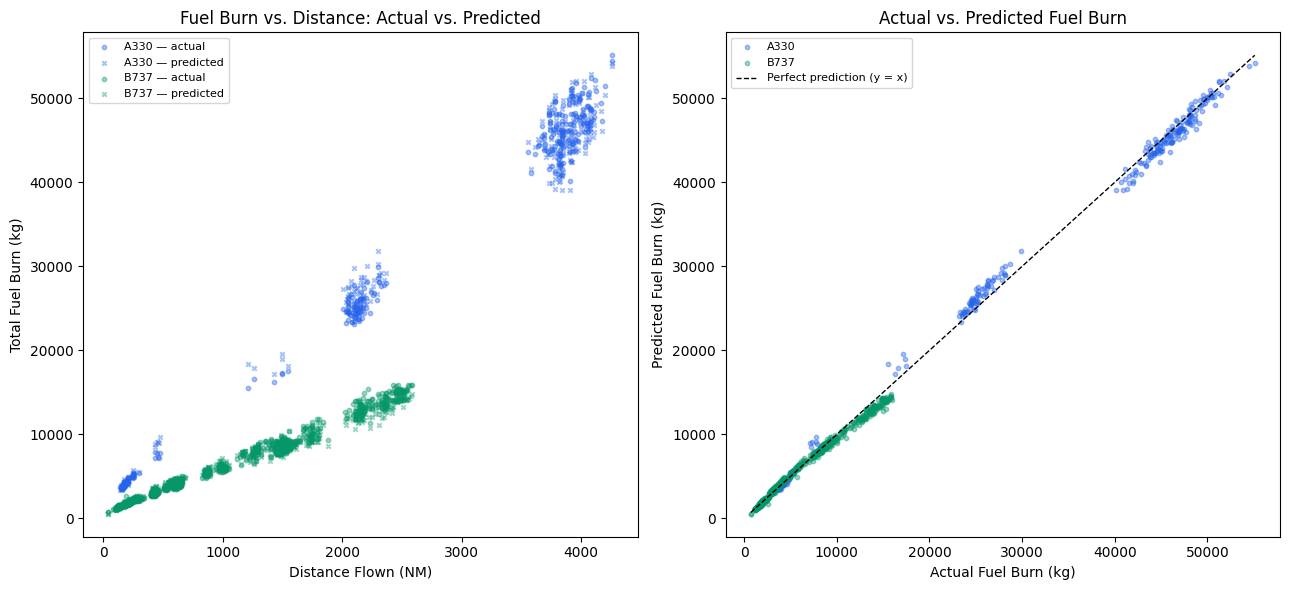

Saved: images/model_validation.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Trained Spark MLlib coefficients (log-linear model, per fleet group)
COEFFICIENTS = {
    "B737": {"intercept": -6.4264, "log_distance": 0.7166, "log_weight": 0.9245, "tailwind": -0.0031},
    "A330": {"intercept": -8.9322, "log_distance": 0.6803, "log_weight": 1.1476, "tailwind": 0.0015},
}

df["Fleet_Group"] = df["Fleet"].apply(lambda f: "A330" if f == "A330" else "B737")

def predict(row):
    c = COEFFICIENTS[row["Fleet_Group"]]
    log_pred = (c["intercept"]
                + c["log_distance"] * np.log(row["Total_Distance_Flown_NM"])
                + c["log_weight"] * np.log(row["Gross_Weight_At_Liftoff_kg"])
                + c["tailwind"] * row["Max_Tailwind_During_Takeoff_kt"])
    return np.exp(log_pred)

df["Predicted_Fuel_Burn_kg"] = df.apply(predict, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
colors = {"A330": "#2563eb", "B737": "#059669"}

# Left: fuel vs distance, actual and predicted overlaid
for group, color in colors.items():
    subset = df[df["Fleet_Group"] == group]
    axes[0].scatter(subset["Total_Distance_Flown_NM"], subset["Total_Fuel_Burn_kg"],
                     s=10, alpha=0.4, color=color, label=f"{group} — actual")
    axes[0].scatter(subset["Total_Distance_Flown_NM"], subset["Predicted_Fuel_Burn_kg"],
                     s=10, alpha=0.4, marker="x", color=color, label=f"{group} — predicted")
axes[0].set_xlabel("Distance Flown (NM)")
axes[0].set_ylabel("Total Fuel Burn (kg)")
axes[0].set_title("Fuel Burn vs. Distance: Actual vs. Predicted")
axes[0].legend(fontsize=8)

# Right: actual vs predicted, with a y=x reference line
for group, color in colors.items():
    subset = df[df["Fleet_Group"] == group]
    axes[1].scatter(subset["Total_Fuel_Burn_kg"], subset["Predicted_Fuel_Burn_kg"],
                     s=10, alpha=0.4, color=color, label=group)
lims = [df["Total_Fuel_Burn_kg"].min(), df["Total_Fuel_Burn_kg"].max()]
axes[1].plot(lims, lims, "k--", linewidth=1, label="Perfect prediction (y = x)")
axes[1].set_xlabel("Actual Fuel Burn (kg)")
axes[1].set_ylabel("Predicted Fuel Burn (kg)")
axes[1].set_title("Actual vs. Predicted Fuel Burn")
axes[1].legend(fontsize=8)

plt.tight_layout()
import os
os.makedirs("images", exist_ok=True)
plt.savefig("images/model_validation.png", dpi=150)
plt.show()
print("Saved: images/model_validation.png")